In [7]:
import torch

print(f"PyTorch 版本: {torch.__version__}")
print(f"GPU 是否可用: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    # 创建一个张量并放到 GPU 上
    device = torch.device("cuda")
    x = torch.ones(3, 3).to(device)
    print("成功在 GPU 上创建张量：")
    print(x)
else:
    print("目前只能使用 CPU")

PyTorch 版本: 2.10.0+cu128
GPU 是否可用: True
成功在 GPU 上创建张量：
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], device='cuda:0')


In [5]:
# Tensor 操作示例
import torch

# Tensor 创建
# 创建一个 2行 3列 的矩阵，里面填满随机数
x = torch.rand(2, 3)

print("内容:\n", x)
print("形状 (Shape):", x.shape)

# Tensor 计算
y = torch.tensor([[1, 2, 3], [4, 5, 6]]) # 手动创建一个矩阵

# 加法
z = x + y 

# 乘法（对应位置相乘）
m = x * y

print("相加后的结果:\n", z)
print("相乘后的结果:\n", m)

# Tensor 传值
# 检查 GPU 还在不在
if torch.cuda.is_available():
    device = torch.device("cuda")
    
    # 把 Tensor 转移到 GPU
    x_gpu = x.to(device)
    y_gpu = y.to(device)
    
    # 这个计算现在是在显卡核心里完成的！
    result = x_gpu + y_gpu
    print("GPU 计算完成！设备:", result.device)

# Tensor 自动求导
# 1. 定义 x，并告诉 PyTorch：帮我盯着这个变量，我以后要对它求导
x = torch.tensor(3.0, requires_grad=True)

# 2. 定义公式
y = x ** 2

# 3. 自动计算（反向传播）
y.backward()

# 4. 打印导数（即 dy/dx）
print(x.grad) # 结果应该是 6.0


内容:
 tensor([[0.3454, 0.2190, 0.6714],
        [0.4214, 0.8473, 0.8468]])
形状 (Shape): torch.Size([2, 3])
相加后的结果:
 tensor([[1.3454, 2.2190, 3.6714],
        [4.4214, 5.8472, 6.8468]])
相乘后的结果:
 tensor([[0.3454, 0.4379, 2.0141],
        [1.6855, 4.2363, 5.0806]])
GPU 计算完成！设备: cuda:0
tensor(6.)


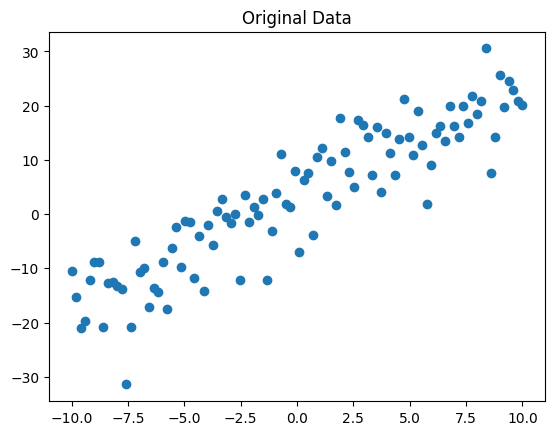

Epoch [20/100], Loss: 37.2387, w: 2.04, b: 0.48
Epoch [40/100], Loss: 33.5678, w: 2.04, b: 1.32
Epoch [60/100], Loss: 31.9317, w: 2.04, b: 1.88
Epoch [80/100], Loss: 31.2024, w: 2.04, b: 2.25
Epoch [100/100], Loss: 30.8774, w: 2.04, b: 2.50
Epoch [120/100], Loss: 30.7326, w: 2.04, b: 2.67
Epoch [140/100], Loss: 30.6680, w: 2.04, b: 2.78
Epoch [160/100], Loss: 30.6392, w: 2.04, b: 2.85
Epoch [180/100], Loss: 30.6264, w: 2.04, b: 2.90
Epoch [200/100], Loss: 30.6207, w: 2.04, b: 2.94


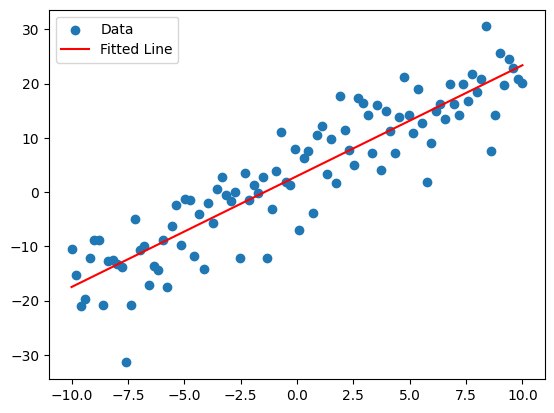

In [6]:
# 线性回归
# 1. 准备数据
import torch
import matplotlib.pyplot as plt

# 1. 构造数据集
# x 为 -10 到 10 的 100 个点
x = torch.linspace(-10, 10, 100).reshape(-1, 1) 

# 假设真实的规律是 y = 2x + 3，我们加点噪声
noise = torch.randn(x.size()) * 5
y_true = 2 * x + 3 + noise

# 画出来看看
plt.scatter(x.numpy(), y_true.numpy())
plt.title("Original Data")
plt.show()

# 2. 初始化训练参数
# 随机初始化参数
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

learning_rate = 0.01 # 学习率：每次调整的步长

# 3. 训练循环
for epoch in range(200):
    # 1. 前向传播：算出当前的预测值
    y_pred = x * w + b
    
    # 2. 计算损失 (Loss)：用均方误差 (MSE)
    # 预测值和真实值差的平方，再取平均。Loss 越小，拟合越准。
    loss = torch.mean((y_pred - y_true) ** 2)
    
    # 3. 反向传播：计算梯度
    loss.backward()
    
    # 4. 更新参数
    # 这一步我们手动更新，不让 PyTorch 记录这个更新动作的梯度
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
        
        # ！！！非常重要：手动清空梯度，否则下次计算会累加
        w.grad.zero_()
        b.grad.zero_()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}, w: {w.item():.2f}, b: {b.item():.2f}")

# 4.绘制结果 
plt.scatter(x.numpy(), y_true.numpy(), label="Data")
plt.plot(x.numpy(), (x * w + b).detach().numpy(), color='red', label="Fitted Line")
plt.legend()
plt.show()
